In [2]:
import nest
import os
import network
import addons
import helpers
import matplotlib.pyplot as plt
import numpy as np
from network_params import net_dict
import network_params
from sim_params import sim_dict
from stimulus_params import stim_dict


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: Apr 15 2024 07:21:32

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



/home/hyc_1/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning:Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.


In [3]:
from scipy.sparse import dok_matrix 
from scipy.fft import fft
from scipy.fft import fftfreq
from scipy import signal
from scipy.signal import butter, lfilter
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.interpolate import pchip
from scipy.interpolate import make_smoothing_spline

def compute_FFT(signal_data,freq_sample= 0.001):
    analysis_interval_start = (addons.analysis_dict["analysis_start"] -500) /0.2
    analysis_interval_end = (addons.analysis_dict["analysis_end"] -500)/ 0.2
    analysis_interval_start = int(analysis_interval_start)
    analysis_interval_end = int(analysis_interval_end)
    FFT_Results = {}

    for i in range(len(signal_data)):
        FFT_Results[i] = fft(signal_data[i][analysis_interval_start:analysis_interval_end]-np.mean(signal_data[i][analysis_interval_start:analysis_interval_end]))

    #Calcular los valores de frequencia correspondientes
    freq = fftfreq(len(signal_data[i][analysis_interval_start:analysis_interval_end]),d=freq_sample)

    indx = int(len(signal_data[i][analysis_interval_start:analysis_interval_end])/2)
    result_fourier = {}

    for i in FFT_Results:
        result_fourier[i] = np.abs(FFT_Results[i])[:indx]
    results_freq = freq[:indx]



    return result_fourier, results_freq, indx

In [4]:
from scipy.stats import entropy as scipy_entropy

def compute_spectral_entropy(result_fourier, results_freq):
    """
    Spectral entropy of the normalised power spectrum.
    H = -sum(P * log(P))  where P is the normalised power (sums to 1).
    """
    spectral_entropy = {}
    for i in result_fourier:
        power        = result_fourier[i] ** 2          # amplitude → power
        power_norm   = power / power.sum()              # normalise to sum=1 (probability dist)
        spectral_entropy[i] = scipy_entropy(power_norm, base=2)   # bits
    return spectral_entropy


def compute_Q_factor(result_fourier, results_freq, target_freq=80.0, freq_window=20.0):
    """
    Q-factor = peak height / bandwidth (−3 dB bandwidth around target_freq).
    target_freq : Hz — centre of search window
    freq_window : Hz — ± search radius around target_freq
    """
    Q_factors    = {}
    peak_freqs   = {}
    peak_heights = {}
    bandwidths   = {}

    for i in result_fourier:
        power = result_fourier[i] ** 2

        # ── find the dominant peak near target_freq ───────────────────────────
        mask          = (results_freq >= target_freq - freq_window) & \
                        (results_freq <= target_freq + freq_window)
        freq_window_  = results_freq[mask]
        power_window  = power[mask]

        if len(power_window) == 0 or power_window.max() == 0:
            Q_factors[i] = np.nan
            peak_freqs[i] = np.nan
            peak_heights[i] = np.nan
            bandwidths[i] = np.nan
            continue

        peak_idx_local = np.argmax(power_window)
        peak_freq      = freq_window_[peak_idx_local]
        peak_height    = power_window[peak_idx_local]

        # ── −3 dB bandwidth ───────────────────────────────────────────────────
        half_power     = peak_height / 2.0          # −3 dB in linear power
        above_half     = power_window >= half_power

        # find left and right edges of the −3 dB region
        transitions    = np.diff(above_half.astype(int))
        rise_idxs      = np.where(transitions ==  1)[0]   # crossing upward
        fall_idxs      = np.where(transitions == -1)[0]   # crossing downward

        # pick the edges closest to the peak
        left_freq  = freq_window_[rise_idxs[rise_idxs  < peak_idx_local][-1]] \
                     if len(rise_idxs[rise_idxs  < peak_idx_local]) > 0 \
                     else freq_window_[0]
        right_freq = freq_window_[fall_idxs[fall_idxs > peak_idx_local][0] + 1] \
                     if len(fall_idxs[fall_idxs > peak_idx_local]) > 0 \
                     else freq_window_[-1]

        bw = right_freq - left_freq

        Q_factors[i]    = peak_freq / bw  if bw > 0 else np.nan
        peak_freqs[i]   = peak_freq
        peak_heights[i] = peak_height
        bandwidths[i]   = bw

    return Q_factors, peak_freqs, peak_heights, bandwidths


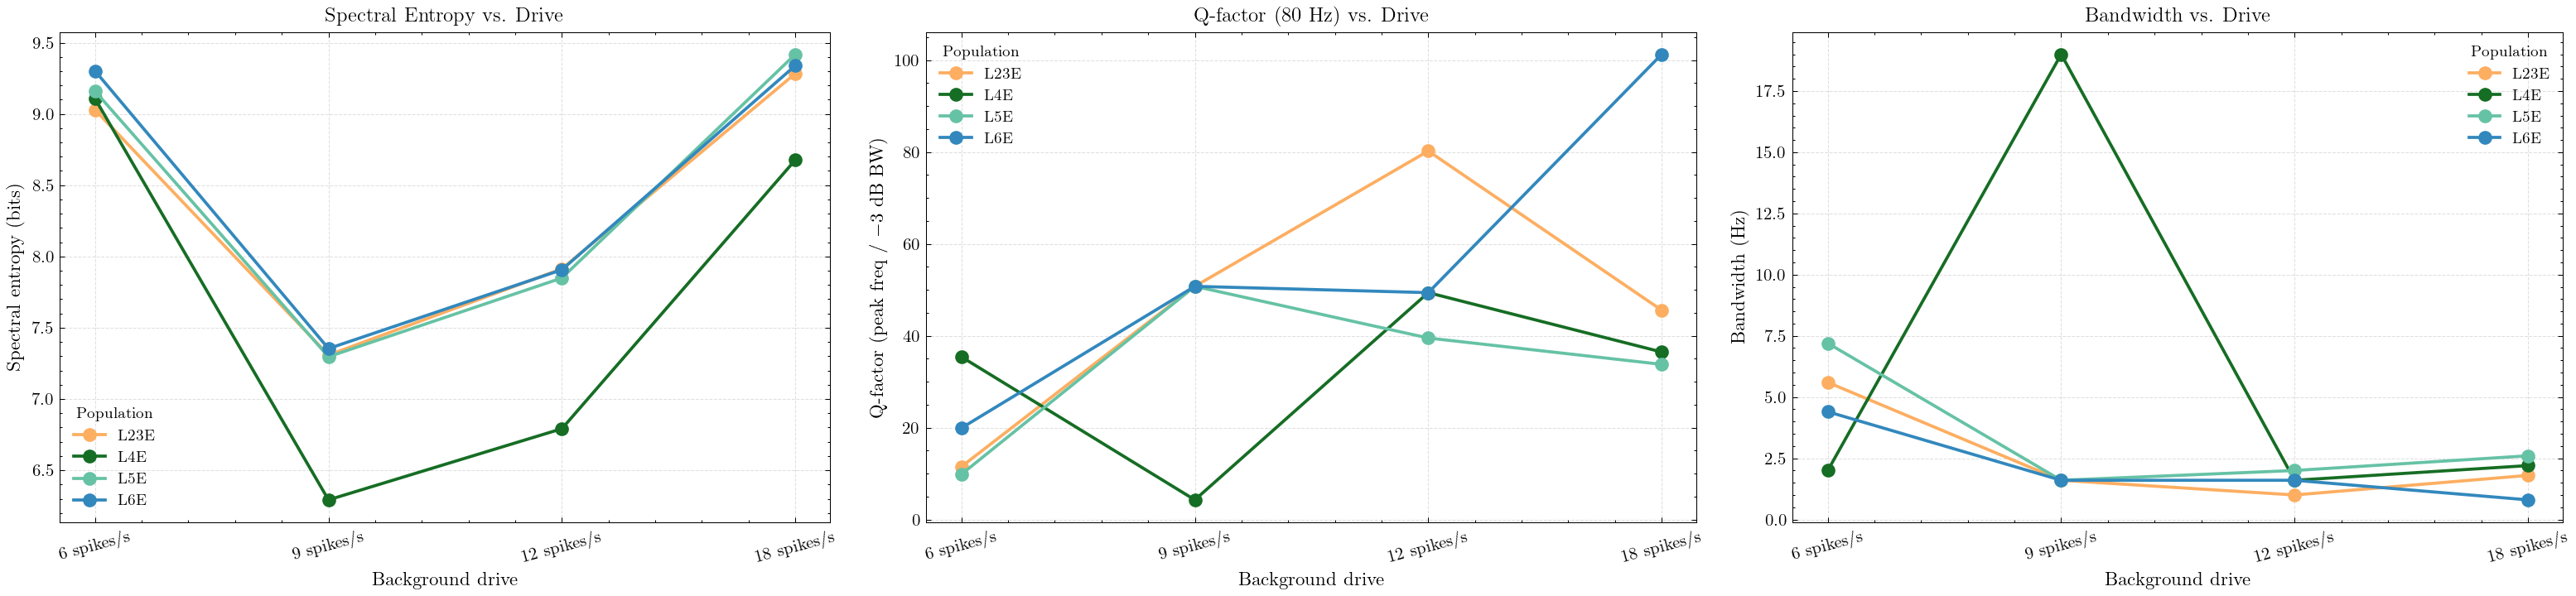

In [5]:
dirs = os.listdir("data_background_rate_fig_1")
dirs = sorted(dirs)

labels_rate = ["6 spikes/s", "9 spikes/s", "12 spikes/s", "18 spikes/s"]
names       = [6, 9, 12, 18]
freq_sample = 0.0002

pops     = ["L23E", "L4E", "L5E", "L6E"]
n_pops   = len(pops)
n_drives = len(dirs)

all_entropy = {}
all_Q       = {}
all_bw      = {}

for i in range(n_drives):
    # ── load population activity for this drive ───────────────────────────
    base = "data_background_rate_fig_1/" + dirs[i] + "/trial_0/"
    pop_activity_i = []
    for j in range(n_pops):
        fpath = base + "measurements/pop_activities/pop_activity_" + str(j * 2) + ".dat"
        pop_activity_i.append(np.loadtxt(fpath))
    pop_activity_i = np.array(pop_activity_i)   # shape: (n_pops, n_timepoints)

    # ── FFT + metrics ─────────────────────────────────────────────────────
    a, b, c = compute_FFT(pop_activity_i, freq_sample=freq_sample)

    all_entropy[i]             = compute_spectral_entropy(a, b)
    all_Q[i], _, _, all_bw[i] = compute_Q_factor(a, b, target_freq=80.0, freq_window=20.0)

# ── Reshape into (n_pops × n_drives) arrays ──────────────────────────────────
entropy_arr = np.array([[all_entropy[d][p] for d in range(n_drives)] for p in range(n_pops)])
Q_arr       = np.array([[all_Q[d][p]       for d in range(n_drives)] for p in range(n_pops)])
bw_arr      = np.array([[all_bw[d][p]      for d in range(n_drives)] for p in range(n_pops)])


x           = np.arange(n_drives)
markers     = ['o', 'o', 'o', 'o']
colors_pops = ['#fdae61', "#166d24", '#66c2a5', '#3288bd']

fig, axes = plt.subplots(1, 3, figsize=(21, 5), dpi=150)

for pop_idx in range(n_pops):
    axes[0].plot(x, entropy_arr[pop_idx],
                 marker=markers[pop_idx], color=colors_pops[pop_idx],
                 linewidth=1.8, markersize=7, label=pops[pop_idx])
    axes[1].plot(x, Q_arr[pop_idx],
                 marker=markers[pop_idx], color=colors_pops[pop_idx],
                 linewidth=1.8, markersize=7, label=pops[pop_idx])
    axes[2].plot(x, bw_arr[pop_idx],
                 marker=markers[pop_idx], color=colors_pops[pop_idx],
                 linewidth=1.8, markersize=7, label=pops[pop_idx])

for ax, title, ylabel in zip(
    axes,
    ["Spectral Entropy vs. Drive", "Q-factor (80 Hz) vs. Drive", "Bandwidth vs. Drive"],
    ["Spectral entropy (bits)", "Q-factor (peak freq / −3 dB BW)", "Bandwidth (Hz)"]
):
    ax.set_xticks(x)
    ax.set_xticklabels(labels_rate, rotation=15)
    ax.set_xlabel("Background drive", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(title="Population", fontsize=9, title_fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

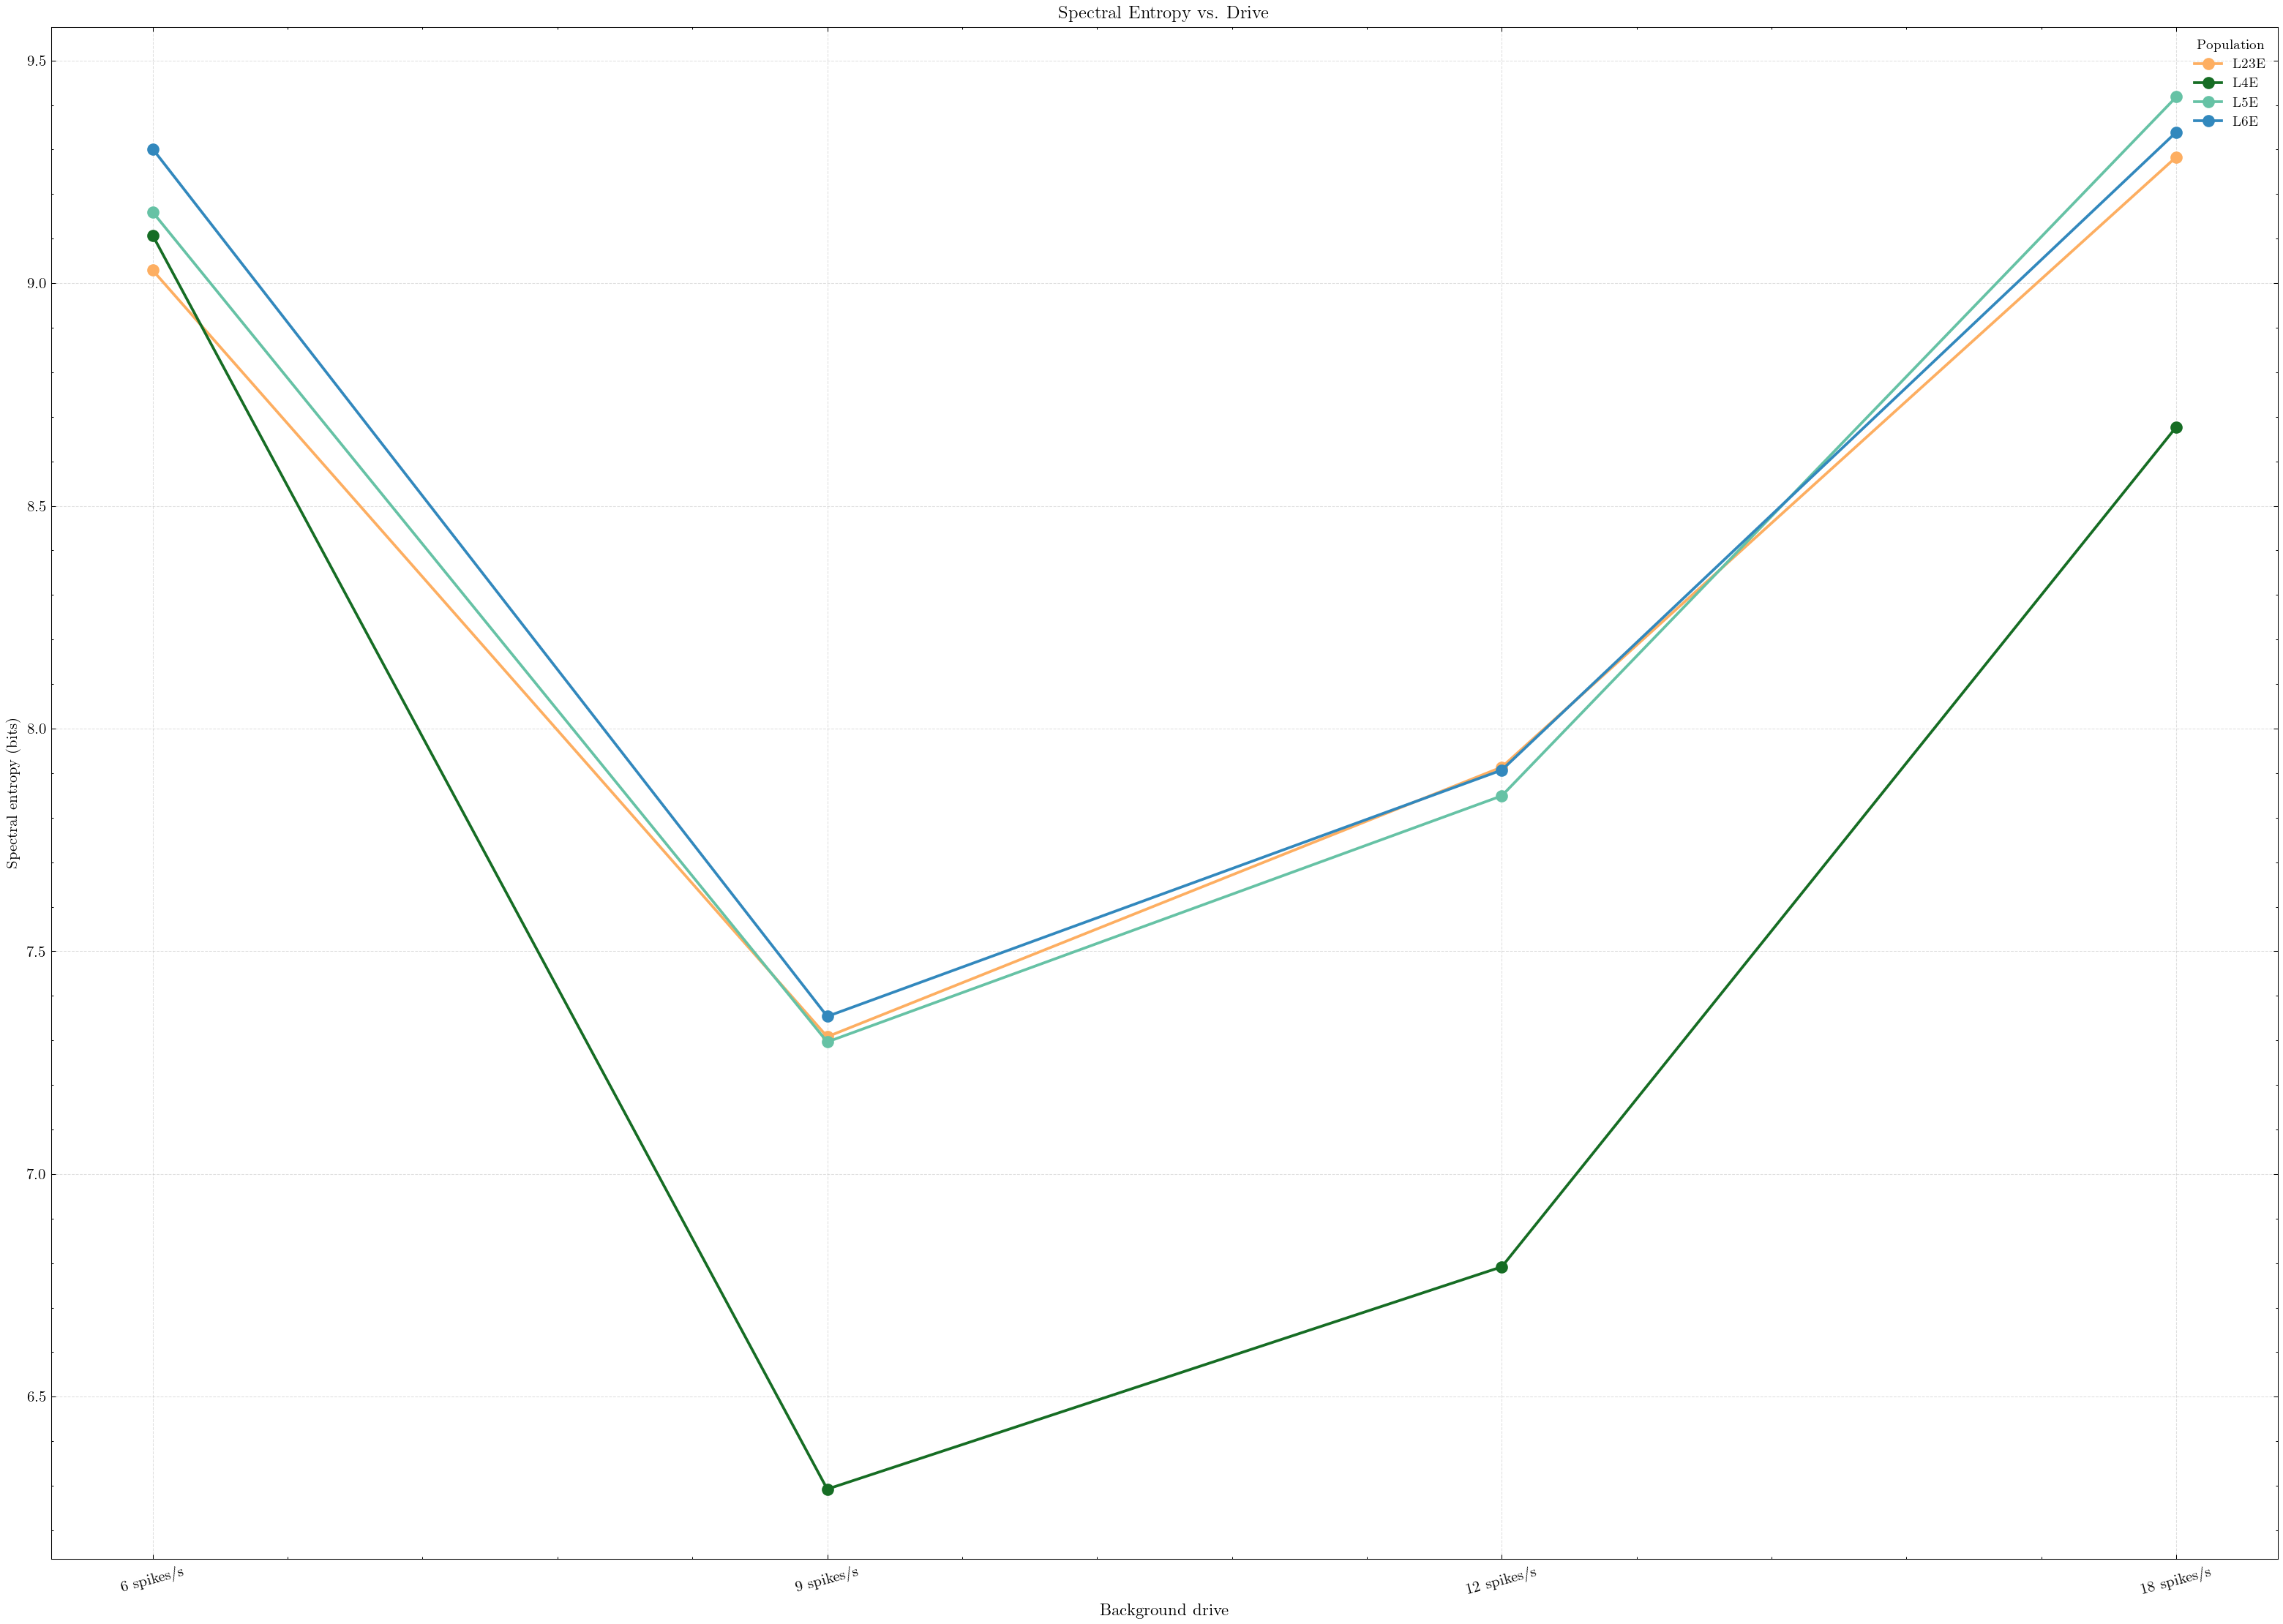

In [9]:
dirs = os.listdir("data_background_rate_fig_1")
dirs = sorted(dirs)

labels_rate = ["6 spikes/s", "9 spikes/s", "12 spikes/s", "18 spikes/s"]
names       = [6, 9, 12, 18]
freq_sample = 0.0002

pops     = ["L23E", "L4E", "L5E", "L6E"]
n_pops   = len(pops)
n_drives = len(dirs)

all_entropy = {}
all_Q       = {}
all_bw      = {}

for i in range(n_drives):
    # ── load population activity for this drive ───────────────────────────
    base = "data_background_rate_fig_1/" + dirs[i] + "/trial_0/"
    pop_activity_i = []
    for j in range(n_pops):
        fpath = base + "measurements/pop_activities/pop_activity_" + str(j * 2) + ".dat"
        pop_activity_i.append(np.loadtxt(fpath))
    pop_activity_i = np.array(pop_activity_i)   # shape: (n_pops, n_timepoints)

    # ── FFT + metrics ─────────────────────────────────────────────────────
    a, b, c = compute_FFT(pop_activity_i, freq_sample=freq_sample)

    all_entropy[i]             = compute_spectral_entropy(a, b)
    all_Q[i], _, _, all_bw[i] = compute_Q_factor(a, b, target_freq=80.0, freq_window=20.0)

# ── Reshape into (n_pops × n_drives) arrays ──────────────────────────────────
entropy_arr = np.array([[all_entropy[d][p] for d in range(n_drives)] for p in range(n_pops)])
Q_arr       = np.array([[all_Q[d][p]       for d in range(n_drives)] for p in range(n_pops)])
bw_arr      = np.array([[all_bw[d][p]      for d in range(n_drives)] for p in range(n_pops)])


x           = np.arange(n_drives)
markers     = ['o', 'o', 'o', 'o']
colors_pops = ['#fdae61', "#166d24", '#66c2a5', '#3288bd']

fig, axes = plt.subplots(1, 1, figsize=(21, 15), dpi=150)

for pop_idx in range(n_pops):
    axes.plot(x, entropy_arr[pop_idx],
                 marker=markers[pop_idx], color=colors_pops[pop_idx],
                 linewidth=1.8, markersize=7, label=pops[pop_idx])

    axes.set_title("Spectral Entropy vs. Drive")
    axes.set_ylabel("Spectral entropy (bits)")
    axes.set_xticks(x)
    axes.set_xticklabels(labels_rate, rotation=15)
    axes.set_xlabel("Background drive", fontsize=11)
    axes.legend(title="Population", fontsize=9, title_fontsize=9)
    axes.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()